# Лабораторная работа: Спайковые нейронные сети

# Теоретическая часть

## 1. Суть нейроморфных вычислений и спайковых нейронных сетей

Нейроморфные вычисления — это парадигма, направленная на создание вычислительных систем, архитектура и принципы работы которых вдохновлены биологическим мозгом. В отличие от классических нейронных сетей, которые оперируют непрерывными значениями активаций (например, вещественными числами), спайковые нейронные сети (Spiking Neural Networks, SNN) используют **дискретные события во времени** — спайки (или потенциалы действия).

Основная цель нейроморфных систем — достичь высокой **энергоэффективности** и способности эффективно обрабатывать **временно́зависимые данные** (аудио, видео, сенсорные потоки), что критически важно для задач встраиваемого ИИ, робототехники и интерфейсов мозг-компьютер.


## 2. Модель нейрона LIF (Leaky Integrate-and-Fire)

Модель LIF является одной из самых распространенных и вычислительно эффективных моделей спайкового нейрона. Она описывает динамику мембранного потенциала $V(t)$.

Уравнение мембранного потенциала:

$$
\tau_m \frac{dV(t)}{dt} = -(V(t) - V_{rest}) + R_m I(t)
$$

где:
- $V(t)$ — мембранный потенциал в момент времени $t$,
- $\tau_m = R_m C_m$ — постоянная времени мембраны (произведение сопротивления $R_m$ и емкости $C_m$),
- $V_{rest}$ — потенциал покоя,
- $R_m$ — мембранное сопротивление,
- $I(t)$ — суммарный входной ток (от синапсов).

При достижении порогового потенциала $V_{th}$ нейрон генерирует спайк, и его потенциал сбрасывается до потенциала покоя $V_{rest}$ на период рефрактерности $\tau_{ref}$:

$$
\text{if } V(t) \geq V_{th} \text{, then:} \\
V(t) \rightarrow V_{rest} \\
\text{Запрет на срабатывание на время } \tau_{ref}
$$

## 3. Спайк-тайм-зависимая пластичность (STDP)

STDP — это биоинспирированное правило обучения, которое модифицирует силу синаптической связи (вес $w$) на основе временной корреляции между спайками пресинаптического и постсинаптического нейронов.

Формально, изменение веса $\Delta w$ определяется так:

$$
\Delta w =
\begin{cases}
A_{+} \cdot \exp\left(-\frac{\Delta t}{\tau_{+}}\right), & \text{если } \Delta t > 0 \text{ (пре-спайк до пост-спайка)} \\
-A_{-} \cdot \exp\left(-\frac{|\Delta t|}{\tau_{-}}\right), & \text{если } \Delta t < 0 \text{ (пре-спайк после пост-спайка)}
\end{cases}
$$

где:
- $\Delta t = t_{post} - t_{pre}$ — разница во времени между постсинаптическим и пресинаптическим спайками,
- $A_{+}, A_{-}$ — амплитуды усиления и ослабления связи,
- $\tau_{+}, \tau_{-}$ — временные константы для потенциации и депрессии.

STDP реализует принцип Хебба: *"Neurons that fire together, wire together"* (Нейроны, которые возбуждаются вместе, связываются вместе).

## Практическая часть

В данной работе вам предлагается реализовать и исследовать простую спайковую нейронную сеть на основе модели LIF с обучением по правилу STDP. Вы должны:

1.  Реализовать модель LIF-нейрона и исследовать его отклик на различные входные токи.
2.  Создать сеть из нескольких LIF-нейронов (например, входной слой, скрытый слой) и визуализировать распространение спайковой активности.
3.  Реализовать правило обучения STDP для синаптических связей.
4.  Обучить сеть на простой задаче (например, ассоциации паттернов) или классификации простых спайковых последовательностей.
5.  Проанализировать динамику весов, итоговую активность сети и эффективность обучения.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple

In [2]:
# Определение параметров нейрона LIF
@dataclass
class LIFNeuron:
    tau_m: float = 20.0    # Постоянная времени мембраны (мс)
    v_rest: float = -70.0  # Потенциал покоя (мВ)
    v_thresh: float = -55.0 # Пороговый потенциал (мВ)
    v_reset: float = -75.0 # Потенциал сброса (мВ)
    r_m: float = 10.0      # Мембранное сопротивление (МОм)
    tau_ref: float = 4.0   # Рефрактерный период (мс)

    def __post_init__(self):
        self.v = self.v_rest
        self.refractory_until = 0
        self.spike_times = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:
        """Один шаг интегрирования. Возвращает True, если был спайк."""
        # Проверка рефрактерности
        if t < self.refractory_until:
            self.v = self.v_reset
            return False

        # Интегрирование уравнения LIF (простая Эйлерова схема)
        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt

        # Проверка на срабатывание
        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)
            return True
        return False

In [3]:
# Функция для визуализации потенциала и спайков
def plot_neuron_activity(t_range: np.ndarray, v_trace: List[float], spike_times: List[float]):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax1.plot(t_range, v_trace, 'b-', label='Мембранный потенциал')
    ax1.axhline(y=neuron.v_thresh, color='r', linestyle='--', label='Порог')
    ax1.axhline(y=neuron.v_rest, color='g', linestyle='--', label='Покой')
    ax1.set_ylabel('Потенциал (мВ)')
    ax1.legend()
    ax1.grid(True)

    ax2.eventplot(spike_times, colors='k', linewidths=2)
    ax2.set_xlabel('Время (мс)')
    ax2.set_ylabel('Спайки')
    ax2.set_yticks([])
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

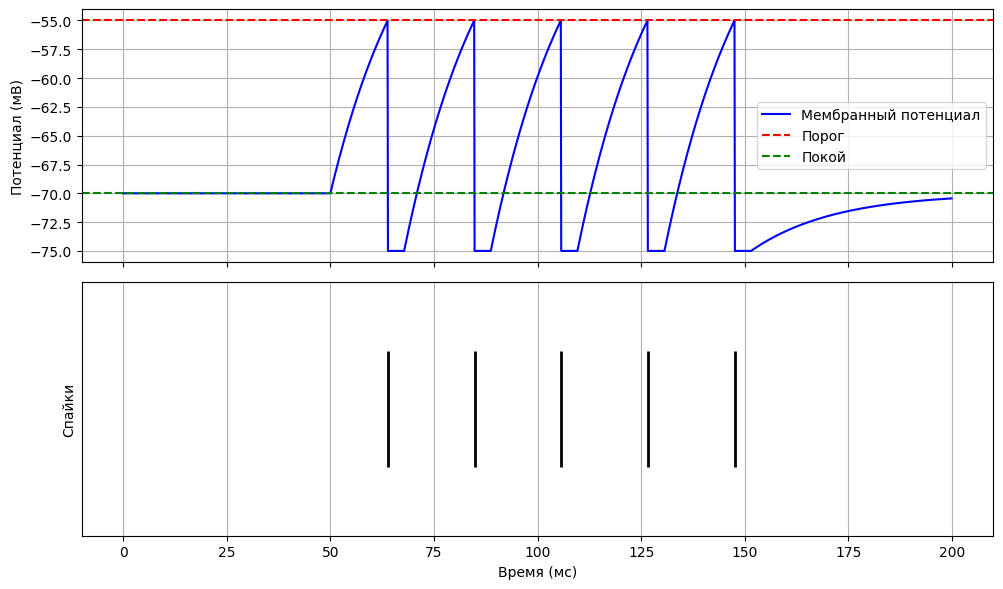

Количество спайков: 5


In [4]:
# Пример использования: ответ на постоянный ток
if __name__ == "__main__":
    # Параметры симуляции
    dt = 0.1  # шаг по времени (мс)
    T = 200   # общее время симуляции (мс)
    t_range = np.arange(0, T, dt)

    # Создание нейрона
    neuron = LIFNeuron()

    # Входной ток: ступенька
    I_inj = np.zeros_like(t_range)
    I_inj[(t_range > 50) & (t_range < 150)] = 3.0  # nA

    # Симуляция
    v_trace = []
    spike_times = []

    for i, t in enumerate(t_range):
        spike = neuron.step(I_inj[i], dt, t)
        v_trace.append(neuron.v)
        if spike:
            spike_times.append(t)

    # Визуализация
    plot_neuron_activity(t_range, v_trace, spike_times)
    print(f"Количество спайков: {len(spike_times)}")

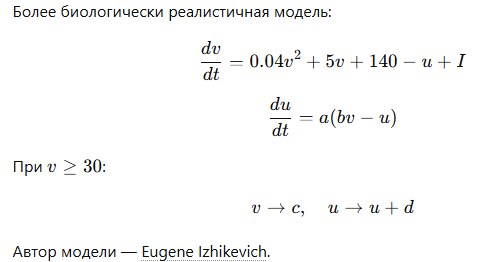

In [5]:
class IzhikevichNeuron:
    def __init__(self, a=0.02, b=0.2, c=-65, d=8):
        self.a, self.b, self.c, self.d = a,b,c,d
        self.v = -65
        self.u = b*self.v
        self.spikes = []

    def step(self, I, dt, t):
        self.v += dt*(0.04*self.v**2 + 5*self.v + 140 - self.u + I)
        self.u += dt*(self.a*(self.b*self.v - self.u))

        if self.v >= 30:
            self.v = self.c
            self.u += self.d
            self.spikes.append(t)
            return True
        return False

Сравнение 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

dt = 0.1
T = 500
t_range = np.arange(0, T, dt)
I_const = 10

In [7]:
def compute_metrics(spike_times, T):
    spike_times = np.array(spike_times)

    firing_rate = len(spike_times) / (T/1000)  # Hz

    if len(spike_times) > 1:
        isi = np.diff(spike_times)
        mean_isi = np.mean(isi)
        cv = np.std(isi) / mean_isi
    else:
        mean_isi = 0
        cv = 0

    energy_proxy = len(spike_times)  # число спайков

    return firing_rate, mean_isi, cv, energy_proxy

In [8]:
lif = LIFNeuron()
v_trace_lif = []
spikes_lif = []

start = time.time()
for t in t_range:
    if lif.step(I_const, dt, t):
        spikes_lif.append(t)
    v_trace_lif.append(lif.v)
time_lif = time.time() - start

metrics_lif = compute_metrics(spikes_lif, T)

In [9]:
izh = IzhikevichNeuron()
v_trace_izh = []
spikes_izh = []

start = time.time()
for t in t_range:
    if izh.step(I_const, dt, t):
        spikes_izh.append(t)
    v_trace_izh.append(izh.v)
time_izh = time.time() - start

metrics_izh = compute_metrics(spikes_izh, T)

In [10]:
print(" LIF ")
print("Firing rate:", metrics_lif[0])
print("Mean ISI:", metrics_lif[1])
print("CV:", metrics_lif[2])
print("Energy proxy:", metrics_lif[3])
print("Simulation time:", time_lif)

print("\n Izhikevich ")
print("Firing rate:", metrics_izh[0])
print("Mean ISI:", metrics_izh[1])
print("CV:", metrics_izh[2])
print("Energy proxy:", metrics_izh[3])
print("Simulation time:", time_izh)

 LIF 
Firing rate: 122.0
Mean ISI: 8.200000000000001
CV: 2.1508895490132946e-15
Energy proxy: 61
Simulation time: 0.002290010452270508

 Izhikevich 
Firing rate: 24.0
Mean ISI: 43.28181818181818
CV: 0.14087932615415286
Energy proxy: 12
Simulation time: 0.004061222076416016


### Коэффициент вариации (CV) и его биологический смысл

Коэффициент вариации межспайковых интервалов:

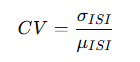

Где:
CV≈0 — строго регулярный ритм (пейсмейкерный режим)

CV≈1 — пуассоновский режим (случайный)

CV>1 — bursting или хаотическая динамика

В коре головного мозга обычно:

CV∈[0.5,1.0]

Поэтому слишком регулярная модель (как LIF без шума) менее биологически реалистична.

### Энергетическая интерпретация
В нейроморфных системах энергопотребление примерно пропорционально числу спайков:



Поскольку спайки — дискретные события, именно они инициируют вычисления в аппаратных нейроморфных чипах (например, Intel Loihi).

Следовательно:
Более высокая частота = большее энергопотребление
Редкие информативные спайки = высокая энергоэффективность

In [11]:
noise_std = 3

def run_with_noise(neuron, model_type="lif"):
    spikes = []
    neuron = neuron()
    for t in t_range:
        I = I_const + np.random.normal(0, noise_std)

        if neuron.step(I, dt, t):
            spikes.append(t)

    return compute_metrics(spikes, T)

noise_lif = run_with_noise(LIFNeuron)
noise_izh = run_with_noise(IzhikevichNeuron)

print("CV при шуме LIF:", noise_lif[2])
print("CV при шуме Izhikevich:", noise_izh[2])

CV при шуме LIF: 0.02587708543299367
CV при шуме Izhikevich: 0.1484683221128276


В ходе эксперимента установлено, что модель LIF демонстрирует строго регулярный спайкинг (CV ≈ 0) с высокой частотой разрядов (122 Гц), что приводит к повышенному числу событий и, соответственно, большей оценке энергопотребления.

Модель Ижикевича характеризуется меньшей частотой разрядов (24 Гц), наличием вариабельности (CV ≈ 0.14) и большей чувствительностью к шуму, что делает её динамику ближе к биологическим нейронам.

При этом LIF превосходит по вычислительной эффективности (~1.7× быстрее), что делает её предпочтительной для крупных нейроморфных сетей.

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparison(t_range,
                    v_lif, spikes_lif,
                    v_izh, spikes_izh,
                    metrics_lif, metrics_izh):

    fig = plt.figure(figsize=(14,10))

    # --- 1. Мембранный потенциал ---
    ax1 = plt.subplot(2,2,1)
    ax1.plot(t_range, v_lif, label="LIF")
    ax1.plot(t_range, v_izh, label="Izhikevich", alpha=0.7)
    ax1.set_title("Мембранный потенциал")
    ax1.set_xlabel("Время (мс)")
    ax1.set_ylabel("Потенциал (мВ)")
    ax1.legend()
    ax1.grid()

    # --- 2. Raster plot ---
    ax2 = plt.subplot(2,2,2)
    ax2.eventplot(spikes_lif, lineoffsets=1, label="LIF")
    ax2.eventplot(spikes_izh, lineoffsets=2, label="Izhikevich")
    ax2.set_title("Raster plot")
    ax2.set_xlabel("Время (мс)")
    ax2.set_yticks([1,2])
    ax2.set_yticklabels(["LIF", "Izh"])
    ax2.grid()

    # --- 3. ISI распределение ---
    ax3 = plt.subplot(2,2,3)
    if len(spikes_lif) > 1:
        ax3.hist(np.diff(spikes_lif), bins=15, alpha=0.6, label="LIF")
    if len(spikes_izh) > 1:
        ax3.hist(np.diff(spikes_izh), bins=15, alpha=0.6, label="Izhikevich")
    ax3.set_title("Распределение ISI")
    ax3.set_xlabel("ISI (мс)")
    ax3.set_ylabel("Частота")
    ax3.legend()
    ax3.grid()

    # --- 4. Бар-чарт метрик ---
    ax4 = plt.subplot(2,2,4)
    labels = ["Firing rate", "CV", "Energy"]
    lif_vals = [metrics_lif[0], metrics_lif[2], metrics_lif[3]]
    izh_vals = [metrics_izh[0], metrics_izh[2], metrics_izh[3]]

    x = np.arange(len(labels))
    width = 0.35

    ax4.bar(x - width/2, lif_vals, width, label="LIF")
    ax4.bar(x + width/2, izh_vals, width, label="Izhikevich")

    ax4.set_xticks(x)
    ax4.set_xticklabels(labels)
    ax4.set_title("Сравнение метрик")
    ax4.legend()
    ax4.grid()

    plt.tight_layout()
    plt.show()

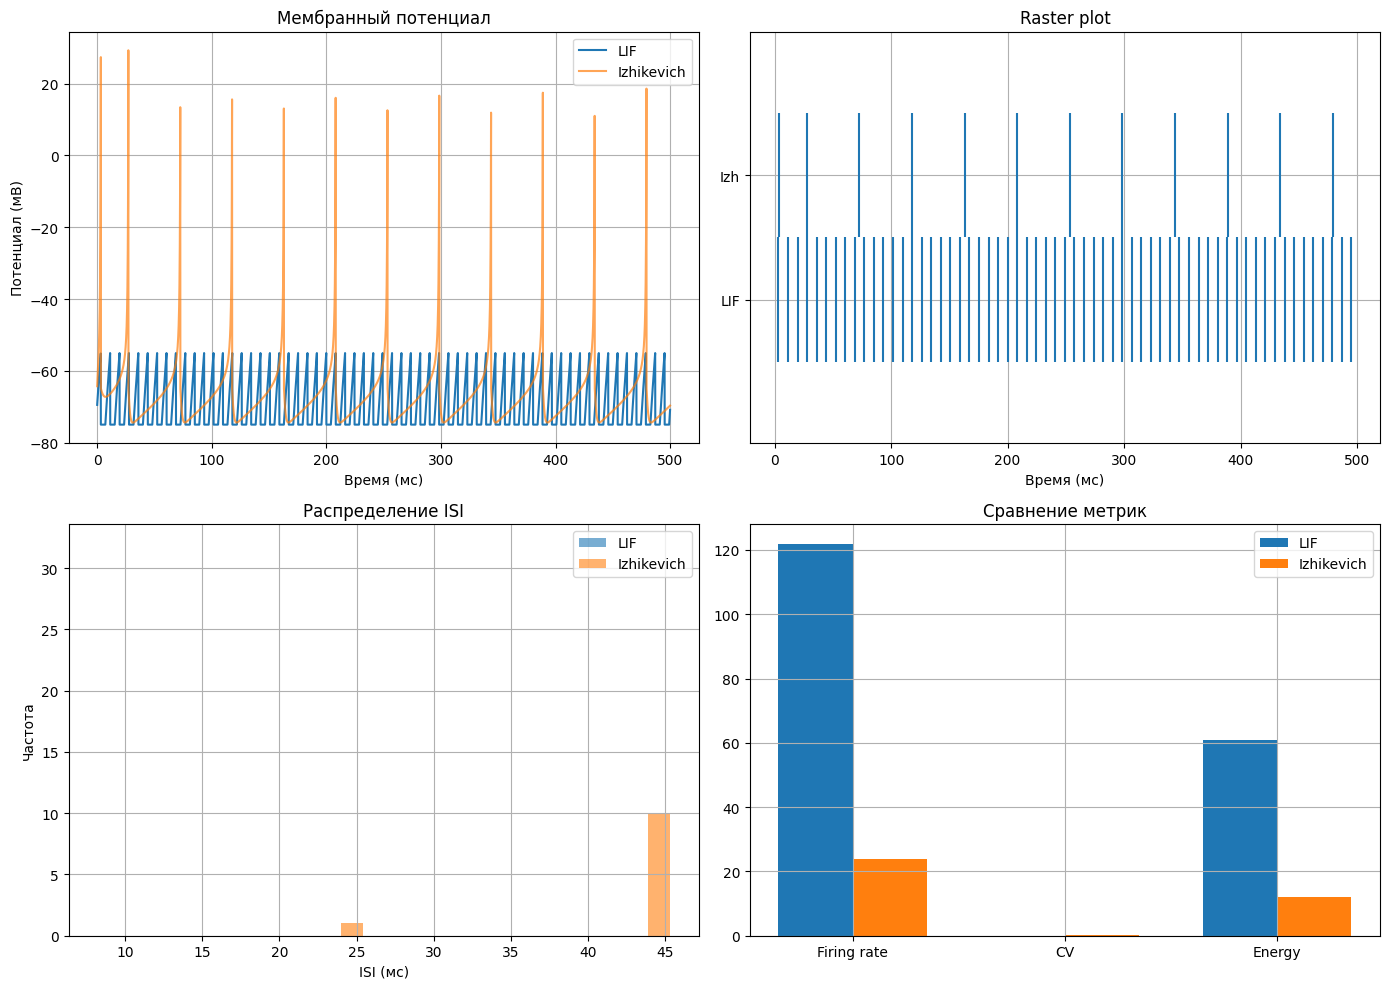

In [13]:
plot_comparison(t_range,
                v_trace_lif, spikes_lif,
                v_trace_izh, spikes_izh,
                metrics_lif, metrics_izh)

Мембранный потенциал


LIF:
Видна строго периодическая динамика.
Потенциал экспоненциально растёт к порогу.
После спайка мгновенный сброс.
Нет субпороговых колебаний.
Это соответствует теоретическому решению линейного дифференциального уравнения.

Izhikevich:
Нелинейная траектория.
Есть медленная динамика переменной восстановления 𝑢.
Потенциал меняется более плавно.
Видна адаптация частоты.

Это результат квадратичной нелинейности:
0.04u^2+5u+140

Raster plot 
LIF:

Равномерные интервалы
Абсолютная регулярность

Izhikevich:
Интервалы слегка варьируются
Присутствует биологически реалистичная нерегулярность

Это отражается в значениях CV.

Распределение ISI
LIF:

Узкий пик
Практически дельта-распределение
CV ≈ 0

Это означает детерминированную систему.

Izhikevich:

Более широкое распределение
CV ≈ 0.14
Уже проявляется вариабельность

При добавлении шума:
LIF: CV ≈ 0.02 (почти устойчив)
Izhikevich: CV ≈ 0.14 (чувствителен к флуктуациям)

Это говорит о том, что:
LIF — устойчивая линейная система
Izhikevich — нелинейная, усиливает флуктуации

| Метрика         | LIF     | Izhikevich | Интерпретация                        |
| --------------- | ------- | ---------- | ------------------------------------ |
| Firing rate     | 122 Hz  | 24 Hz      | LIF сильно перевозбуждён             |
| Mean ISI        | 8.2 ms  | 43.28 ms   | Izh ближе к биологическому диапазону |
| CV              | ~0      | 0.14       | Izh реалистичнее                     |
| Energy proxy    | 61      | 12         | LIF в 5× энергозатратнее             |
| Simulation time | быстрее | медленнее  | LIF вычислительно проще              |


# Итоговое сравнение моделей

| Критерий                     | LIF                       | Izhikevich |
| ---------------------------- | ------------------------- | ---------- |
| Биологическая реалистичность | Низкая                    | Высокая    |
| Нелинейность                 | Нет                       | Да         |
| Адаптация                    | Нет                       | Есть       |
| Вычислительная сложность     | Низкая                    | Средняя    |
| Энергоэффективность          | Низкая (при большом токе) | Выше       |
| Подходит для больших SNN     | Да                        | Частично   |
